Name:- Tanmay Santosh Sanap

Roll No:-40

Student Id:- 5144978

College:- B K BIRLA COLLEGE

Subject:-Data Engineering (Practical No :- 04)

To perform noise elimination, feature selection, and exploratory data analysis (EDA) using Python libraries.

Original Dataset:
   Age  Marks  Attendance  Constant
0   20     75          85         1
1   21     80          88         1
2   22     85          90         1
3   23     90          92         1
4   24     95          94         1
5  100     20          50         1

Q1: 21.25
Q3: 23.75
IQR: 2.5
Lower Limit: 17.5
Upper Limit: 27.5

Dataset after Noise Elimination:
   Age  Marks  Attendance  Constant
0   20     75          85         1
1   21     80          88         1
2   22     85          90         1
3   23     90          92         1
4   24     95          94         1

Selected Features:
Index(['Age', 'Marks', 'Attendance'], dtype='object')

Dataset with Selected Features:
   Age  Marks  Attendance
0   20     75          85
1   21     80          88
2   22     85          90
3   23     90          92
4   24     95          94

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  D

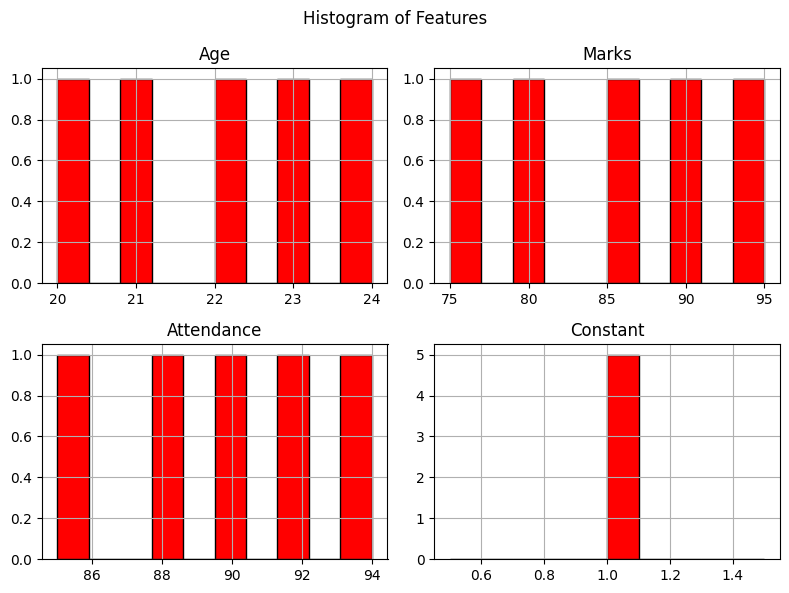

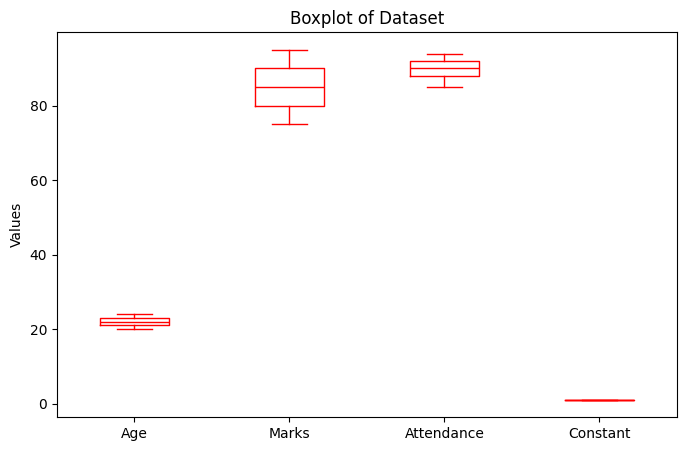

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# ----------------------------
# Sample Dataset
# ----------------------------

data = {
    'Age': [20, 21, 22, 23, 24, 100],       # 100 is an outlier
    'Marks': [75, 80, 85, 90, 95, 20],
    'Attendance': [85, 88, 90, 92, 94, 50],
    'Constant': [1, 1, 1, 1, 1, 1]          # Constant feature
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)


# =====================================
# 1. Noise Elimination (Outlier Removal)
# =====================================

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)

# Remove Age outlier
df_clean = df[
    (df['Age'] >= lower) &
    (df['Age'] <= upper)
]

print("\nDataset after Noise Elimination:")
print(df_clean)


# =====================================
# 2. Feature Selection
# Remove Constant / Low Variance Features
# =====================================

selector = VarianceThreshold(threshold=0.0)

selected = selector.fit_transform(df_clean)

selected_columns = df_clean.columns[
    selector.get_support()
]

print("\nSelected Features:")
print(selected_columns)

# Display selected dataset
df_selected = df_clean[selected_columns]

print("\nDataset with Selected Features:")
print(df_selected)


# =====================================
# 3. Exploratory Data Analysis (EDA)
# =====================================

print("\nDataset Information:")
df_clean.info()


# =====================================
# Statistical Summary
# =====================================

print("\nStatistical Summary:")
print(df_clean.describe())


# =====================================
# Correlation Matrix
# =====================================

print("\nCorrelation Matrix:")
print(df_clean.corr())


# =====================================
# 4. Histogram
# =====================================

df_clean.hist(
    figsize=(8, 6),
    color='red',
    edgecolor='black'
)

plt.suptitle("Histogram of Features")
plt.tight_layout()
plt.show()


# =====================================
# 5. Boxplot
# =====================================

plt.figure(figsize=(8, 5))

df_clean.boxplot(
    color='red'
)

plt.title("Boxplot of Dataset")
plt.ylabel("Values")
plt.grid(False)

plt.show()